# Fixed-batch memorization benchmark

**What it measures.** Can each optimizer *memorize a single fixed minibatch* on a
tall-skinny MLP — drive its training loss toward 0 and its batch accuracy to 1.0 —
and how fast, both per iteration and per wall-clock second? We compare the
trust-region optimizer (exact dense subproblem solver) against plain SGD across
three activations (tanh, gelu, relu). The same first 32-example minibatch is reused
for the whole run (`--reuse-batch 1000000`), isolating raw optimization power from
generalization.

## Fixed configuration

All six runs share the same model and data:

```
--image-size 8 --hidden-dim 8 --num-layers 16 --batch-size 32
--seed 0 --reuse-batch 1000000 --data-dir ./data
```

a width-8, depth-16 MLP memorizing one 32-example batch of 8×8 CIFAR-10.

The six runs (method × activation):

- **Trust-region** (dense solver), one per activation:
  `--mode trust-region --tr-solver dense --delta-init 1.0 --delta-max 100 --tr-eta 0.1 --num-steps 400`
- **SGD**, one per activation, with a per-activation tuned learning rate
  (tanh `--lr 0.01`, gelu `--lr 0.03`, relu `--lr 0.01`): `--mode sgd --num-steps 30000`

The exact CLI args live in `memorization/experiments.py`, the single source of truth
imported by both `run.py` and `plot.py`.

## How to run

The figure below renders inline from the committed CSVs. To regenerate the data,
run (from the repo root, using the project venv):

```bash
python benchmarks/memorization/run.py    # runs all six configs (~10-15 min)
```

`run.py` launches `src/train_newton.py` as a subprocess per config, parses its
per-step stderr, and writes `memorization/results/<name>.csv` with columns
`step,loss,batch_accuracy,wall_clock_s`. Pass config names (`tr_tanh`, `sgd_gelu`, …)
to run a subset; the default is all six. The cell below then renders the figure by
importing `plot`.

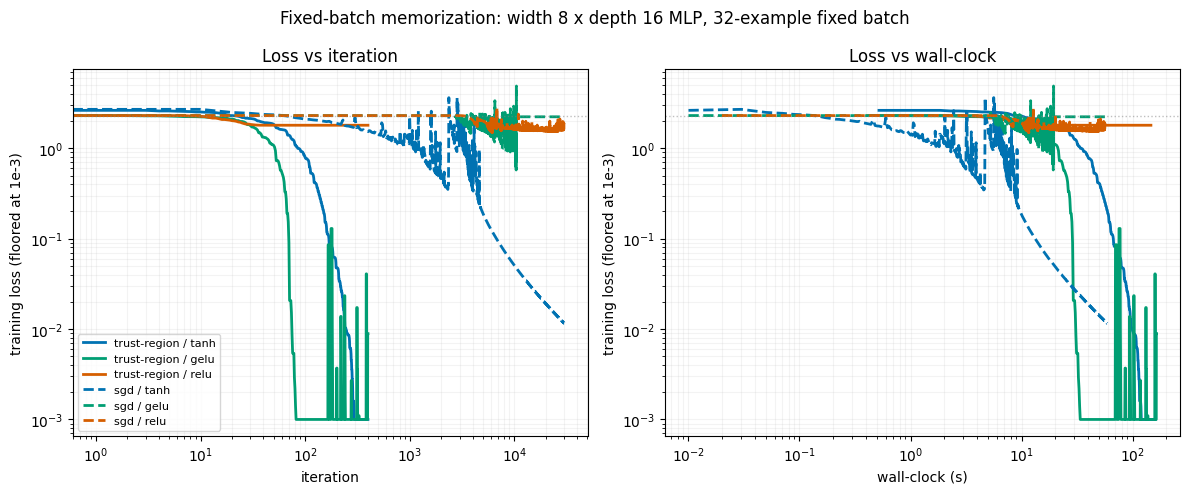

In [1]:
import pathlib, sys

# Make the benchmark's own modules importable no matter where the notebook runs.
for cand in (pathlib.Path.cwd() / "memorization",
             pathlib.Path.cwd() / "benchmarks" / "memorization"):
    if cand.exists():
        sys.path.insert(0, str(cand))
        break

%matplotlib inline
import plot

fig = plot.build_figure()

## Findings

Fresh run (seed 0, CPU), one 32-example fixed batch:

| Run      | Method       | Activation | Min loss | Best batch acc | Step → 100% | Wall-clock → 100% |
|----------|--------------|------------|----------|----------------|-------------|-------------------|
| tr_tanh  | trust-region | tanh       | 0.0003   | 1.000          | 122         | 48.39 s           |
| tr_gelu  | trust-region | gelu       | 0.0000   | 1.000          | 67          | 27.65 s           |
| tr_relu  | trust-region | relu       | 1.7993   | 0.188          | never       | –                 |
| sgd_tanh | sgd          | tanh       | 0.0116   | 1.000          | 4400        | 8.66 s            |
| sgd_gelu | sgd          | gelu       | 0.5755   | 0.875          | never       | –                 |
| sgd_relu | sgd          | relu       | 1.4900   | 0.344          | never       | –                 |

*(“Step → 100%” / “Wall-clock → 100%” are the first iteration / wall-clock time at which batch accuracy hits 1.0.)*

- **Where trust-region works, it memorizes in far fewer iterations than SGD.** On gelu
  and tanh it reaches 100% batch accuracy in a couple hundred iterations or fewer; SGD
  needs thousands. gelu is the fastest activation for TR, then tanh.
- **SGD can still win wall-clock for tanh**, because each SGD step is ~1000× cheaper than
  a dense trust-region step (which eigendecomposes the full Hessian every iteration).
  Fewer, far more expensive Newton-like steps do not always beat many cheap gradient steps
  on the clock.
- **gelu is memorized by trust-region but not by plain SGD** at these settings. Suggestive,
  not conclusive: plain constant-LR SGD is a weak baseline; a momentum/Adam baseline is
  needed before claiming gelu is genuinely hard for first-order methods.
- **relu is memorized by neither.** Its kinks give a Hessian whose sign flips across the
  non-differentiable seams; the trust-region radius repeatedly collapses (steps rejected)
  and SGD stalls on the same fixed batch.